In [1]:
# standard python imports
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import tidy3d as td
# from tidy3d import web
from tidy3d.plugins.resonance import ResonanceFinder
from tidy3d.plugins.polyslab import ComplexPolySlab
rng = np.random.default_rng(12345)

ne_coeffs = [(2.2454, 0.01242), (1.3005, 0.05313), (6.8972, 331.33)]
no_coeffs = [(2.4272, 0.01478), (1.4617, 0.05612), (9.6536, 371.216)]
ln_no= td.Sellmeier(coeffs=no_coeffs)
ln_ne= td.Sellmeier(coeffs=ne_coeffs)
ln = td.AnisotropicMedium(xx=ln_no, yy=ln_ne, zz=ln_no) # x-axis = ne 그러나 구조 만들때 머리 깨지 않게 y쪽으로 ne 넣어줌

sio2_coeffs = [(0.6961663, 0.0684**2),  (0.40794, 0.11624**2),  (0.8974794, 9.89616**2)]
sio2= td.Sellmeier(coeffs=sio2_coeffs)

air = td.Medium(permittivity=1.0)

H = 0.6
# 시간 없어서 일단 변수명 그대로 사용
Hc = 0.33   #etched
Ht = H-Hc   #slab
w_wg=0.25
amplitude=0.7
eff_inf=100


wavelength0 = 1.55
freq0 = td.C_0 / wavelength0
fwidth = freq0 / 40.0
freq_range=np.array((freq0-fwidth/2, freq0+fwidth/2))

In [ ]:
# Simulation parameters
runtime_fwidth = 200.0  # in units of 1/frequency bandwidth of the source
t_start_fwidth = 5.0  # time to start monitoring after source has decayed, units of 1/frequency bandwidth
dPML = 1.0  # space between PhC slabs and PML, in unit of longest wavelength of interest

# Structure parameters (um)
a_lattice = 0.435  # lattice constant "a"

# Simulation size
spacing = dPML * 2  # space between PhC slabs and PML
sim_size = Lx, Ly, Lz = (a_lattice, a_lattice+w_wg+amplitude*2+spacing, 2 * spacing + Ht)

# Number of k values to sample, per edge of the irreducible Brillouin zone -으에에에엥
Nk = 10

# Runtime
run_time = runtime_fwidth / fwidth/4
print(f"Total runtime = {(run_time*1e12):.2f} ps")
t_start = t_start_fwidth / fwidth

# Number of dipoles and monitors
num_dipoles = 7
num_monitors = 2

# Dipole polarization and symmetry
polarization = "Ey"
symmetry = (0, -1, 0)

Total runtime = 10.34 ps


In [ ]:
slab = td.Structure(
    geometry=td.Box(
        center=(0, 0, -Ht/2-Hc/2),
        size=(td.inf, td.inf, Ht),
    ),
    medium=ln,
    name="slab",
)


vertices =[(-eff_inf,-eff_inf),(eff_inf,-eff_inf),(eff_inf,eff_inf),(-eff_inf,eff_inf)]
slab_sio2 = td.Structure(
    geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(-eff_inf, -Hc/2-Ht)), medium=sio2
)


# 사인파 형태로 너비를 정의하는 함수 - 왜...???
x=np.linspace(-a_lattice,a_lattice,100)
def sinusoidal_width(x, A=0.5, wavelength=5, phase=0,off_set=1):
    return A * (np.sin(2 * np.pi * x / wavelength + phase+np.pi/2)+1)/2+off_set

def square_width(x, A=0.5, wavelength=5, phase=0,off_set=1):
    #return A * (np.sin(2 * np.pi * x / wavelength + phase+np.pi/2)+1)/2+off_set
    return A* np.heaviside(np.mod(x-wavelength*0.5+wavelength*0.2,wavelength)-(wavelength*0.4), 0)+off_set



y_upper = square_width(x, amplitude, wavelength=a_lattice, phase=0,off_set=w_wg/2)
y_lower = -y_upper  # 대칭적인 하단 부분
vertices = np.column_stack((x, y_upper))  # 윗부분의 꼭짓점
vertices = np.vstack([vertices, np.column_stack((x[::-1], y_lower[::-1]))])  # 아랫부분 꼭짓점 결합

sidewall_angle=np.pi*(90-75)/180
LN_grating = td.Structure(
    geometry=td.PolySlab(vertices=vertices, axis=2, slab_bounds=(-Hc/2, Hc/2)), medium=ln
)

s = ComplexPolySlab(
    vertices=vertices,
    slab_bounds=(-Hc/2, Hc/2),
    axis=2,
    sidewall_angle=sidewall_angle,
    reference_plane="top",
)


structures = [td.Structure(geometry=s.geometry_group, medium=ln),slab,slab_sio2]

In [4]:

dipole_positions = rng.uniform(
    [-Lx / 2, 0, 0], [Lx / 2, Ly / 8, 0], [num_dipoles, 3]
)

dipole_phases = rng.uniform(0, 2 * np.pi, num_dipoles)

pulses = []
dipoles = []
for i in range(num_dipoles):
    pulse = td.GaussianPulse(freq0=freq0, fwidth=fwidth, phase=dipole_phases[i])
    pulses.append(pulse)
    dipoles.append(
        td.PointDipole(
            source_time=pulse,
            center=tuple(dipole_positions[i]),
            polarization=polarization,
            name="dipole_" + str(i),
        )
    )

In [5]:
monitor_positions = rng.uniform(
    [-Lx / 2, 0, 0], [Lx / 2, Ly / 8, 0], [num_monitors, 3]
)

monitors_time = []
for i in range(num_monitors):
    monitors_time.append(
        td.FieldTimeMonitor(
            fields=["Hz"],
            center=tuple(monitor_positions[i]),
            size=(0, 0, 0),
            start=t_start,
            name="monitor_time_" + str(i),
        )
    )

In [6]:
sim = td.Simulation(
    center=(0, 0, 0),
    size=sim_size,
    grid_spec=td.GridSpec.auto(),
    structures=structures,
    sources=dipoles,
    monitors=monitors_time,
    run_time=run_time,
    shutoff=0,
    normalize_index=None,
    symmetry=symmetry,
    medium=sio2,
)


start_time = sim.run_time - 2 / freq0
field_profile_monitor = td.FieldTimeMonitor(
    center=(0, 0, 0),
    size=(Lx, Ly, 0),
    start=start_time,
    name="fieldProfileMon",
)

14:46:53 대한민국 표준시 WARNING: A bound of simulation.structures[0] (no `name`
                         was specified) was detected as being within the        
                         simulation PML. We recommend extending structures to   
                         infinity or completely outside of the simulation PML to
                         avoid unexpected effects when the structures are not   
                         translationally invariant within the PML.              

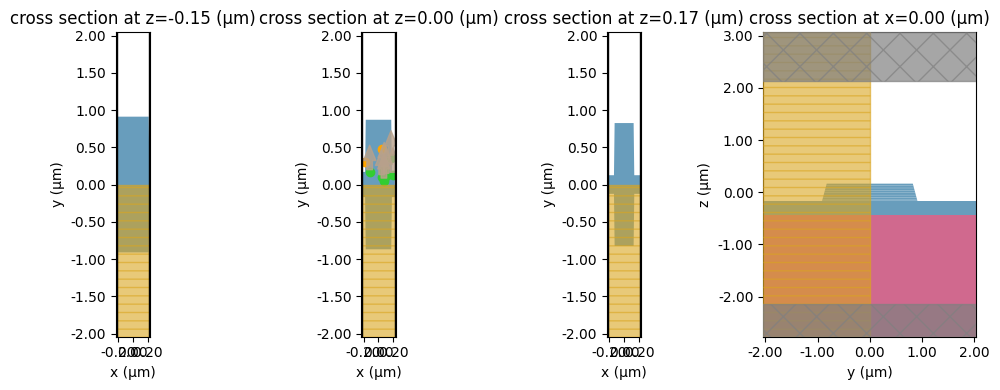

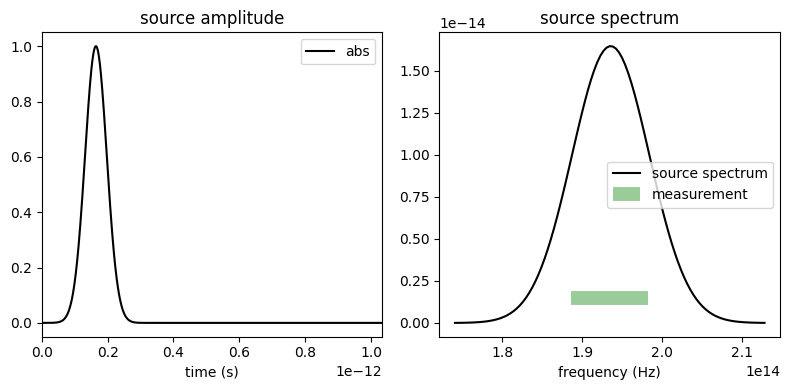

In [7]:
bspecs_gammax = []

for i in range(Nk):
    bspecs_gammax.append(
        td.BoundarySpec(
            x=td.Boundary.bloch((1 / 2)+0.02* (i-Nk/2) / Nk),
            y=td.Boundary.periodic(),
            z=td.Boundary.pml(),
        )
    )

bspecs = bspecs_gammax 

# grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20)
sims = {}
for i in range(Nk):
    sims[f"sim_{i}"] = td.Simulation(
        center=(0, 0, 0),
        size=sim_size,
        grid_spec=grid_spec,
        structures=structures,
        sources=dipoles,
        monitors=monitors_time,
        run_time=run_time,
        shutoff=0,
        boundary_spec=bspecs[i],
        normalize_index=None,
        symmetry=symmetry,
        medium=air,
    )

fig, ax = plt.subplots(1, 4, tight_layout=True, figsize=(10, 4))
sims["sim_0"].plot(z=-Hc/2+0.01, ax=ax[0])
sims["sim_0"].plot(z=0 , ax=ax[1])
sims["sim_0"].plot(z=Hc/2 , ax=ax[2])
sims["sim_0"].plot(x=0, freq=freq0, ax=ax[3])

plt.show()

plt.show()
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(8, 4))
plot_time = 5 / fwidth
ax1 = (
    sims["sim_0"]
    .sources[0]
    .source_time.plot(times=np.linspace(0, plot_time, 1001), val="abs", ax=ax1)
)
ax1.set_xlim(0, plot_time)
ax2 = (
    sims["sim_0"]
    .sources[0]
    .source_time.plot_spectrum(
        times=np.linspace(0, sims["sim_0"].run_time, 10001), val="abs", ax=ax2
    )
)
ax2.hlines(1.5e-15, freq0-fwidth, freq0+fwidth, linewidth=10, color="g", alpha=0.4)

ax2.legend(("source spectrum", "measurement"))
plt.show()